In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import os

In [ ]:
# Extract the filename with and without extension
csv_filename = os.path.basename(csv_file)
csv_title = os.path.splitext(csv_filename)[0]  # Get filename without extension

# Read CSV file as a pandas dataframe
df = pd.read_csv(csv_file)

In [9]:
# Creating a variable for the type column 
groupby_cell = Calcium_Data.groupby('Type')
# Iterate through the groups and calculate the mean of 'Tau' for each group
for type, group in groupby_cell:
    print((type, group['Tau'].mean()))

('Ank', np.float64(0.47214285714285714))
('Ctrl', np.float64(0.48971428571428577))


In [10]:
# convert the values in the 'Type' column of the Calcium_Data DataFrame into a categorical type with a specific order of categories
df['Type'] = pd.Categorical(df['Type'], categories=['Ank', 'Ctrl'])

In [13]:
# Calculate the mean, standard deviation, and median for each cell type
mean_values = df.groupby('Type', observed=False)['Tau'].mean()
std_values = df.groupby('Type', observed=False)['Tau'].std()
median_values = df.groupby('Type', observed=False)['Tau'].median()

In [15]:
# Stat tests
ank_tau = df[df['Type'] == 'Ank']['Tau']
ctrl_tau = df[df['Type'] == 'Ctrl']['Tau']
t_stat, p_value = sc.stats.ttest_ind(ank_tau, ctrl_tau)  

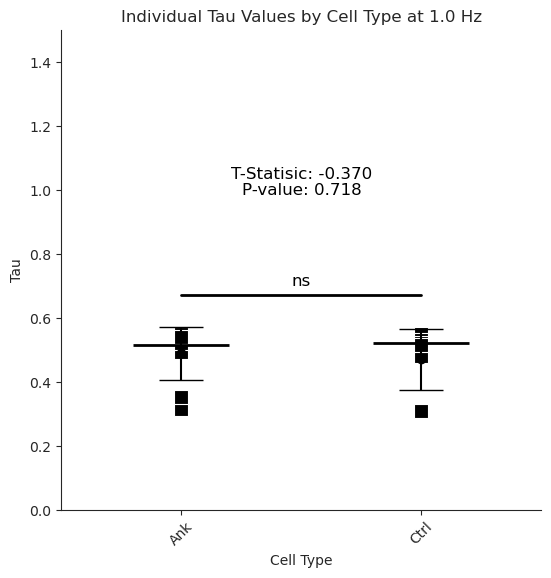

In [16]:
# Create plot features
plt.figure(figsize=(6, 6))

sns.set_style("ticks")
sns.despine()

# Create a scatter plot with Seaborn (individual points)
sns.scatterplot(data=df, x='Type', y='Tau', color='black', marker= 's', s=100, edgecolor='w', alpha=1)
sns.despine()

# Customize the plot
plt.xlabel('Cell Type')
plt.ylabel('Tau')
plt.title('Individual Tau Values by Cell Type at 1.0 Hz')
plt.xticks(rotation=45)
plt.ylim(0, 1.5)
plt.xlim(-0.5, len(Calcium_Data['Type'].unique()) - 0.5)

# Add the p-value annotation to the plot
# 'x' and 'y' are the coordinates where you want to place the p-value text
plt.text(0.5, 1.0, f"P-value: {p_value:.3f}", ha='center', va='center', fontsize=12, color='black')
plt.text(0.5, 1.05, f"T-Statisic: {t_stat:.3f}", ha='center', va='center', fontsize=12, color='black')
# Adjust the layout and show the plot
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)


# Add error bars (standard deviation)
for i, cell_type in enumerate(df['Type'].unique()):
    plt.errorbar(x=i, y=mean_values[cell_type], yerr=std_values[cell_type], fmt='o', color='black', capsize=16, linestyle='None')

# Add horizontal lines for the median of each cell type
for i, cell_type in enumerate(Calcium_Data['Type'].unique()):
    plt.hlines(median_values[cell_type], i - 0.2, i + 0.2, colors='black', linewidth=2, label=f'{cell_type} median' if i == 0 else "")

if p_value > 0.05:
    # Get the positions of the tops of the error bars for each group
    top_ank = mean_values['Ank'] + std_values['Ank']
    top_ctrl = mean_values['Ctrl'] + std_values['Ctrl']
    
    # Determine the y-position for the significance line, slightly above the highest error bar
    top_position = max(top_ank, top_ctrl) + 0.1  # Adding a small buffer above the highest error bar
    
    # Draw a horizontal line connecting the two points (Ank and Ctrl) just above the error bars
    plt.plot([0, 1], [top_position, top_position], color='black', lw=2)
    
    # Add "ns" text to indicate no significance, centered above the line
    plt.text(0.5, top_position + 0.02, 'ns', ha='center', va='bottom', fontsize=12, color='black')


#plt.savefig("Individual_Tau_Values.png", dpi=300) 

plt.show()